# Backtesting — Kupiec Proportion-of-Failures Test

Holds out the final 252 trading days as a test period, re-estimates VaR using **only** the training data, then counts how many days in the test year actually breached the VaR estimate. The Kupiec POF test is a likelihood-ratio test asking whether the observed breach rate is statistically consistent with the model's claimed confidence level.

- Null hypothesis: observed breach rate = model's claimed breach rate (1 − confidence)
- p-value > 0.05 → model is **not** rejected (good)
- p-value ≤ 0.05 → model is rejected (miscalibrated)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm

# Load portfolio returns
portfolio_returns = pd.read_csv("../data/portfolio_returns.csv", index_col=0, parse_dates=True).squeeze()

# Train/test split: last 252 days (~1 trading year) is test
train = portfolio_returns.iloc[:-252]
test  = portfolio_returns.iloc[-252:]

print(f"Training: {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} days)")
print(f"Testing:  {test.index[0].date()} to {test.index[-1].date()}  ({len(test)} days)")

Training: 2019-01-03 to 2023-12-28  (1256 days)
Testing:  2023-12-29 to 2024-12-30  (252 days)


## Kupiec POF test function

In [2]:
def kupiec_pof(breaches, n, p_model):
    """
    Likelihood-ratio proportion-of-failures test.
    H0: true breach rate = p_model.
    Returns (LR statistic, p-value).
    """
    # Handle degenerate cases where breach rate is 0 or 1 (one log term vanishes)
    if breaches == 0:
        lr = -2 * n * np.log(1 - p_model)
    elif breaches == n:
        lr = -2 * n * np.log(p_model)
    else:
        p_hat = breaches / n
        log_restricted   = breaches * np.log(p_model) + (n - breaches) * np.log(1 - p_model)
        log_unrestricted = breaches * np.log(p_hat)   + (n - breaches) * np.log(1 - p_hat)
        lr = -2 * (log_restricted - log_unrestricted)
    p_value = 1 - chi2.cdf(lr, df=1)
    return lr, p_value

## Run backtest at 95% and 99% confidence

In [3]:
rows = []
for conf_label, alpha in [("95%", 0.05), ("99%", 0.01)]:
    # Historical VaR from training data
    hist_var = np.percentile(train, alpha * 100)
    hist_breaches = int((test < hist_var).sum())
    lr_h, p_h = kupiec_pof(hist_breaches, len(test), alpha)

    # Parametric VaR from training data (mu, sigma)
    mu, sd = train.mean(), train.std()
    para_var = mu + norm.ppf(alpha) * sd   # norm.ppf(alpha) is negative
    para_breaches = int((test < para_var).sum())
    lr_p, p_p = kupiec_pof(para_breaches, len(test), alpha)

    expected = len(test) * alpha
    rows.append([conf_label, "Historical", hist_var, expected, hist_breaches, lr_h, p_h,
                 "Not rejected" if p_h > 0.05 else "Rejected"])
    rows.append([conf_label, "Parametric", para_var, expected, para_breaches, lr_p, p_p,
                 "Not rejected" if p_p > 0.05 else "Rejected"])

results = pd.DataFrame(rows, columns=[
    "Confidence", "Method", "VaR (return)", "Expected breaches",
    "Actual breaches", "LR stat", "p-value", "Verdict"
])
results.round(4)

,Confidence,Method,VaR (return),Expected breaches,Actual breaches,LR stat,p-value,Verdict
0,95%,Historical,-0.0161,12.60,6,4.4771,0.0344,Rejected
1,95%,Parametric,-0.0178,12.60,5,6.1962,0.0128,Rejected
2,99%,Historical,-0.0314,2.52,0,5.0654,0.0244,Rejected
3,99%,Parametric,-0.0254,2.52,2,0.1166,0.7327,Not rejected


## Visualize: test-period returns with VaR thresholds

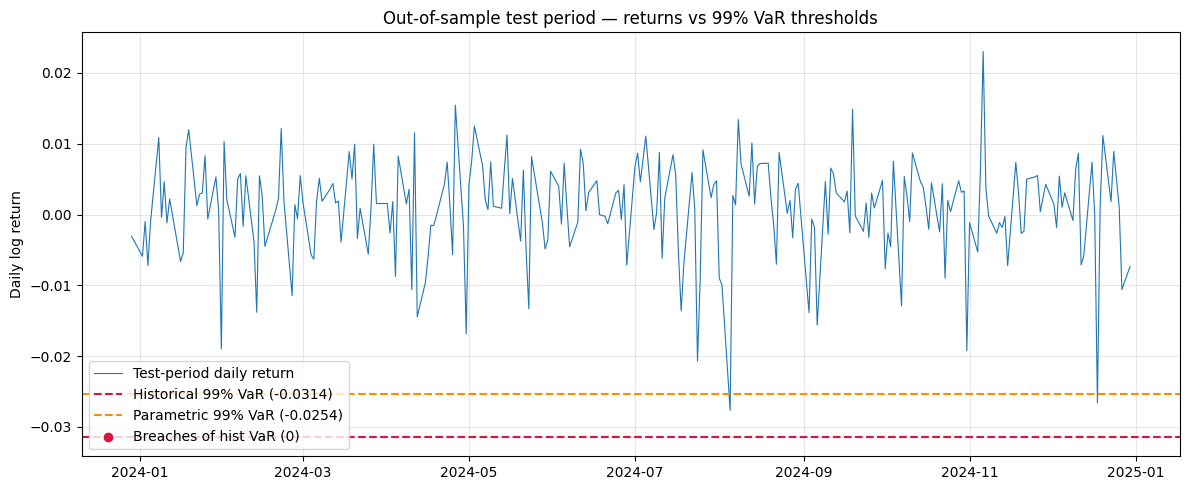

In [4]:
mu, sd = train.mean(), train.std()
h99 = np.percentile(train, 1)
p99 = mu + norm.ppf(0.01) * sd

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test.values, linewidth=0.8, label="Test-period daily return")
ax.axhline(h99, linestyle="--", color="crimson", label=f"Historical 99% VaR ({h99:.4f})")
ax.axhline(p99, linestyle="--", color="darkorange", label=f"Parametric 99% VaR ({p99:.4f})")

# Highlight breach days (breaches of historical VaR)
breach_mask = test < h99
ax.scatter(test.index[breach_mask], test.values[breach_mask],
           color="crimson", zorder=5, label=f"Breaches of hist VaR ({breach_mask.sum()})")

ax.set_title("Out-of-sample test period — returns vs 99% VaR thresholds")
ax.set_ylabel("Daily log return")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

Read off the `results` table above and write a sentence for each row. The four possibilities:

| Verdict | What it means |
| --- | --- |
| `Not rejected`, breaches ≈ expected | Model is well-calibrated |
| `Rejected`, breaches **>** expected | Model **underestimates** risk (dangerous — real-world losses exceed VaR more often than predicted) |
| `Rejected`, breaches **<** expected | Model **overestimates** risk (overly conservative — ties up too much capital) |
| `Not rejected`, breaches far from expected | Sample too small to conclude either way |

A conservative model is a very different failure mode from an underestimating one — make sure your report distinguishes which direction you failed in, not just that you failed.